In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
noncoding = pd.read_csv('/home/apatil2/Disease_risk_modeling/filtered_data_link/data/clinvar_20240805.noncoding.txt',
                sep = '\t',
                low_memory = False)

In [4]:
# noncoding['Transcript'].value_counts()

In [5]:
# noncoding['Consequence'].value_counts()

In [6]:
noncoding.shape

(95760, 17)

In [7]:
coding = pd.read_csv('/home/apatil2/Disease_risk_modeling/filtered_data_link/clinvar_20240805.missense_matched.txt',
                sep = '\t',
                low_memory = False)

In [8]:
coding.shape

(686107, 39)

## Data Exploration

In [9]:
coding.head(), coding.shape

(  Ensembl_Transcript CHROM       POS              ID REF ALT      pLI  \
 0  ENST00000001146.7     2  72132238  2:72132238:C:T   C   T  0.97987   
 1  ENST00000001146.7     2  72132576          432606   C   T  0.97987   
 2  ENST00000001146.7     2  72133081          432607   C   T  0.97987   
 3  ENST00000001146.7     2  72133114  2:72133114:C:T   C   T  0.97987   
 4  ENST00000001146.7     2  72133123  2:72133123:C:G   C   G  0.97987   
 
    gnomAD_AF_popmax  gnomAD3_AF   UKBB_AF    GERP    Eigen  FATHMM   M_CAP  \
 0          0.000058    0.000026  0.000015  0.8645   5.0470  0.7320  0.0500   
 1          0.000009    0.000013 -1.000000  0.6915   6.5425  0.6815  0.0290   
 2         -1.000000   -1.000000 -1.000000  0.8645  12.7365  0.9740  0.3570   
 3          0.000055   -1.000000  0.000010  0.1865   1.2580  0.6815  0.0135   
 4         -1.000000   -1.000000 -1.000000  0.4220   0.9240  0.6860  0.0380   
 
    MetaRNN  MetaSVM     MPC  MutationAssessor  MutationTaster     MVP  \
 0  

In [10]:
noncoding.shape

(95760, 17)

In [11]:
coding.info()

<class 'pandas.DataFrame'>
RangeIndex: 686107 entries, 0 to 686106
Data columns (total 39 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Ensembl_Transcript  686107 non-null  str    
 1   CHROM               686107 non-null  str    
 2   POS                 686107 non-null  int64  
 3   ID                  686107 non-null  str    
 4   REF                 686107 non-null  str    
 5   ALT                 686107 non-null  str    
 6   pLI                 686107 non-null  str    
 7   gnomAD_AF_popmax    686107 non-null  float64
 8   gnomAD3_AF          686107 non-null  float64
 9   UKBB_AF             686107 non-null  float64
 10  GERP                686107 non-null  float64
 11  Eigen               686107 non-null  float64
 12  FATHMM              686107 non-null  float64
 13  M_CAP               686107 non-null  float64
 14  MetaRNN             686107 non-null  float64
 15  MetaSVM             686107 non-null  float64


In [12]:
noncoding.info()

<class 'pandas.DataFrame'>
RangeIndex: 95760 entries, 0 to 95759
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                95760 non-null  int64  
 1   CHROM             95760 non-null  str    
 2   POS               95760 non-null  int64  
 3   REF               95760 non-null  str    
 4   ALT               95760 non-null  str    
 5   CLNDN             95760 non-null  str    
 6   CLNREVSTAT        95760 non-null  str    
 7   CLNSIGCONF        95760 non-null  str    
 8   Pathogenicity     95760 non-null  str    
 9   Symbol            95760 non-null  str    
 10  Transcript        95760 non-null  str    
 11  Consequence       95760 non-null  str    
 12  AAChange          95760 non-null  str    
 13  gnomAD_AF_popmax  95760 non-null  float64
 14  UKBB_AF           95760 non-null  float64
 15  Ensembl           95760 non-null  str    
 16  OMIM              95760 non-null  str    
dtypes: f

### Checking for null values

In [13]:
coding.isna().sum()

Ensembl_Transcript    0
CHROM                 0
POS                   0
ID                    0
REF                   0
ALT                   0
pLI                   0
gnomAD_AF_popmax      0
gnomAD3_AF            0
UKBB_AF               0
GERP                  0
Eigen                 0
FATHMM                0
M_CAP                 0
MetaRNN               0
MetaSVM               0
MPC                   0
MutationAssessor      0
MutationTaster        0
MVP                   0
Polyphen2_HVAR        0
PrimateAI             0
PROVEAN               0
SIFT4G                0
gMVP                  0
VEST4                 0
REVEL                 0
CADD                  0
EVE                   0
Pathogenicity         0
CLNSIGCONF            0
Symbol                0
Gene                  0
Uniprot               0
OMIM                  0
AApos                 0
AAref                 0
AAalt                 0
Protein               0
dtype: int64

In [14]:
noncoding.isna().sum()

ID                  0
CHROM               0
POS                 0
REF                 0
ALT                 0
CLNDN               0
CLNREVSTAT          0
CLNSIGCONF          0
Pathogenicity       0
Symbol              0
Transcript          0
Consequence         0
AAChange            0
gnomAD_AF_popmax    0
UKBB_AF             0
Ensembl             0
OMIM                0
dtype: int64

In [15]:
print(f'Number of coding variants is: {coding['Pathogenicity'].shape[0]}')
print(f'Distribution of coding variants: {coding['Pathogenicity'].value_counts()}')


Number of coding variants is: 686107
Distribution of coding variants: Pathogenicity
B    637191
P     48916
Name: count, dtype: int64


In [16]:
print(f'Number of noncoding variants is: {noncoding['Pathogenicity'].shape[0]}')
print(f'Distribution of noncoding variants: {noncoding['Pathogenicity'].value_counts()}')


Number of noncoding variants is: 95760
Distribution of noncoding variants: Pathogenicity
B    94475
P     1285
Name: count, dtype: int64


In [17]:
coding['gnomAD_AF_popmax'].value_counts()

gnomAD_AF_popmax
-1.000000    565891
 0.000008     21665
 0.000032     11767
 0.000062      8989
 0.000029      7129
              ...  
 0.000494         1
 0.000579         1
 0.002324         1
 0.001195         1
 0.000990         1
Name: count, Length: 1073, dtype: int64

Text(0, 0.5, 'Frequency')

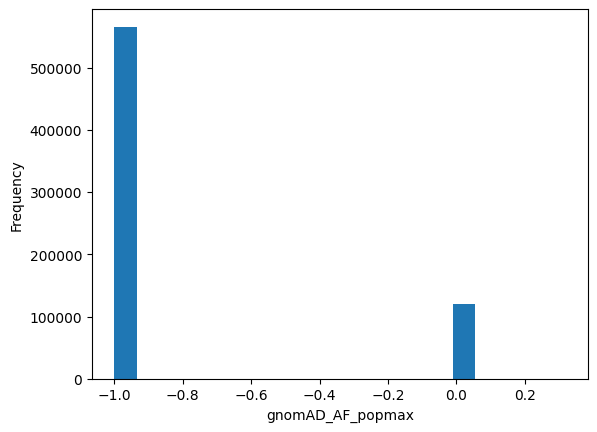

In [18]:
plt.hist(coding['gnomAD_AF_popmax'], bins = 20)
plt.xlabel('gnomAD_AF_popmax')
plt.ylabel('Frequency')

### Distribution of variants across chromosome

In [19]:
dist_p_coding = coding[coding['Pathogenicity']=='P'].groupby('CHROM')['Pathogenicity'].count().reset_index()
dist_b_coding = coding[coding['Pathogenicity']=='B'].groupby('CHROM')['Pathogenicity'].count().reset_index()

dist_b_noncoding = noncoding[noncoding['Pathogenicity']=='B'].groupby('CHROM')['Pathogenicity'].count().reset_index()
dist_p_noncoding = noncoding[noncoding['Pathogenicity']=='P'].groupby('CHROM')['Pathogenicity'].count().reset_index()

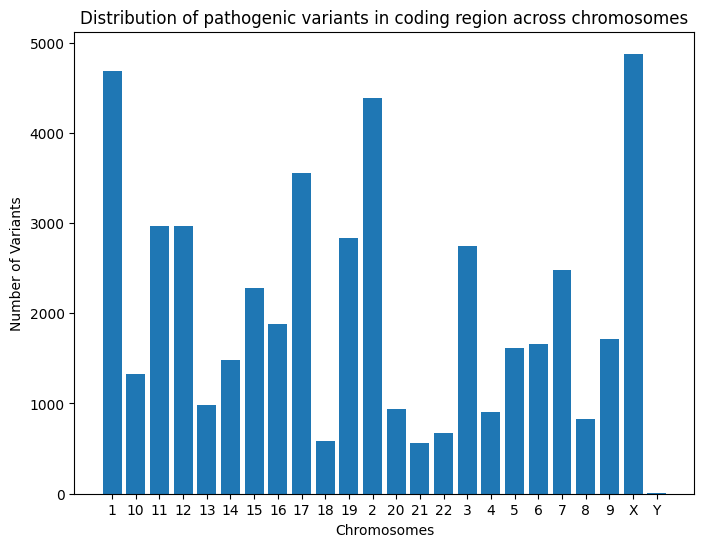

In [20]:
plt.figure(figsize=(8,6))
plt.bar(dist_p_coding['CHROM'], dist_p_coding['Pathogenicity'])
plt.title('Distribution of pathogenic variants in coding region across chromosomes')
plt.xlabel('Chromosomes')
plt.ylabel('Number of Variants')
plt.show()

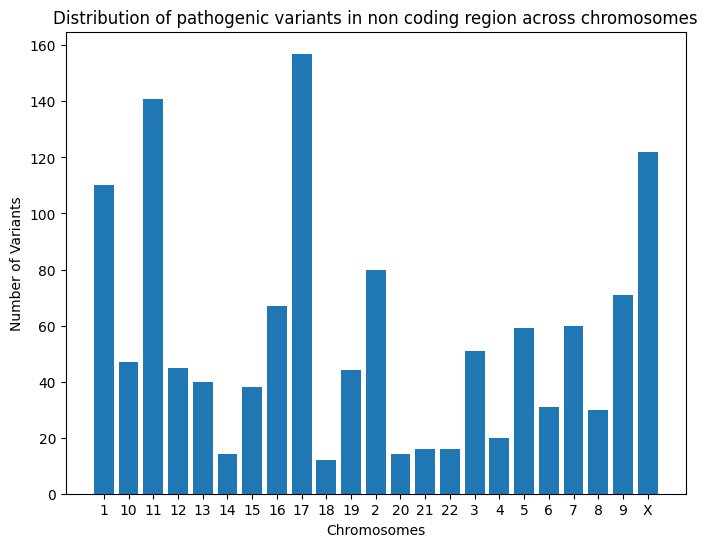

In [21]:
plt.figure(figsize=(8,6))
plt.bar(dist_p_noncoding['CHROM'], dist_p_noncoding['Pathogenicity'])
plt.title('Distribution of pathogenic variants in non coding region across chromosomes')
plt.xlabel('Chromosomes')
plt.ylabel('Number of Variants')
plt.show()

### REF/ALT Distribution

In [22]:
def filter_snvs(df):
    df = df[(df['REF'].str.len() == 1) & (df['ALT'].str.len() == 1)]
    return df

coding = filter_snvs(coding)
noncoding = filter_snvs(noncoding)

In [23]:
def mutation_counts(df):
    df['Mutation'] = df['REF'] + '->' + df['ALT']
    return df['Mutation'].value_counts().reset_index()

print(f'The number of mutations in coding region are \n{mutation_counts(coding)}')
print(f'The number of mutations in noncoding region are \n{mutation_counts(noncoding)}')

The number of mutations in coding region are 
   Mutation   count
0      C->T  124104
1      G->A  120521
2      T->C   86633
3      A->G   81991
4      C->G   49476
5      G->C   49444
6      G->T   36544
7      C->A   36107
8      T->G   30403
9      A->C   30137
10     T->A   20599
11     A->T   20148
The number of mutations in noncoding region are 
   Mutation  count
0      C->T  17990
1      G->A  17785
2      A->G  12848
3      T->C  12719
4      C->G   5366
5      G->C   5320
6      G->T   4829
7      C->A   4771
8      T->G   3957
9      A->C   3752
10     A->T   3266
11     T->A   3157


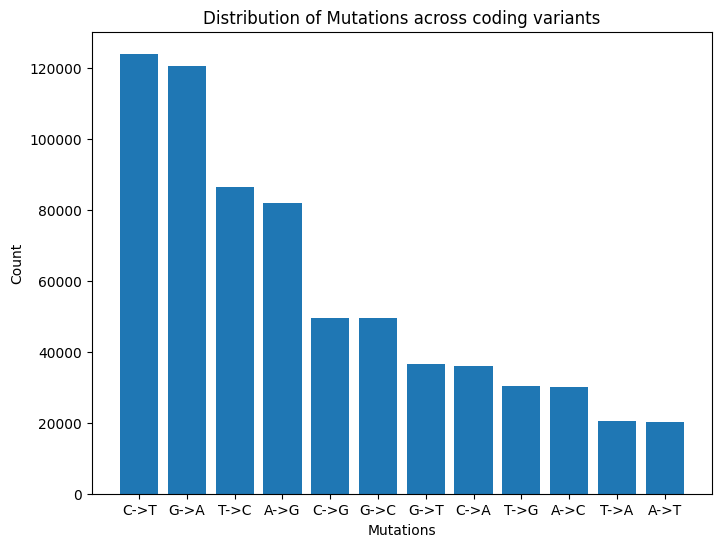

In [29]:
mutations_coding = coding['Mutation'].value_counts().reset_index()
plt.figure(figsize=(8,6))
plt.bar(mutations_coding['Mutation'], mutations_coding['count'])
plt.title('Distribution of Mutations across coding variants')
plt.xlabel('Mutations')
plt.ylabel('Count')
plt.show()

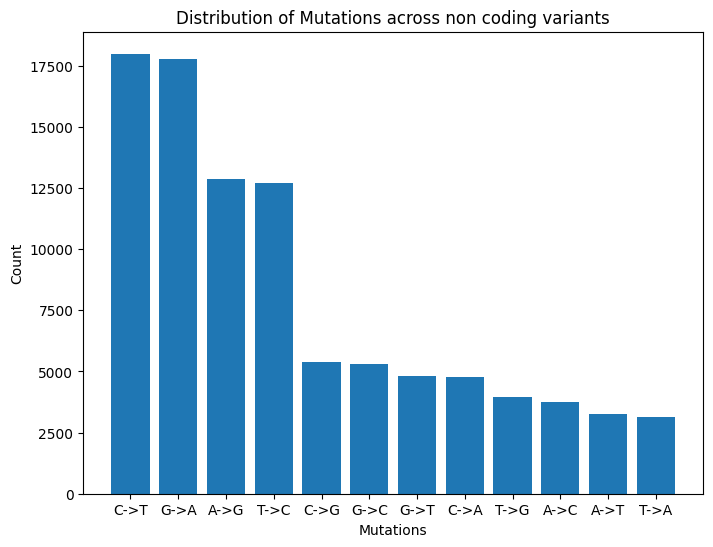

In [31]:
mutations_noncoding = noncoding['Mutation'].value_counts().reset_index()
plt.figure(figsize=(8,6))
plt.bar(mutations_noncoding['Mutation'], mutations_noncoding['count'])
plt.title('Distribution of Mutations across non coding variants')
plt.xlabel('Mutations')
plt.ylabel('Count')
plt.show()

In [24]:
transitions = {('A', 'G'), ('G', 'A'), ('C', 'T'), ('T', 'C')}

def compute_titv(df):
    ti = 0
    tv = 0
    
    for r, a in zip(df['REF'], df['ALT']):
        if (r, a) in transitions:
            ti += 1
        else:
            tv += 1
        
    return ti, tv, ti/tv

coding_ti, coding_tv, coding_ratio = compute_titv(coding)
noncoding_ti, noncoding_tv, noncoding_ratio = compute_titv(noncoding)
print(f"Coding Ti: {coding_ti}, Tv: {coding_tv}, Ti/Tv: {coding_ratio:.3f}")
print(f"Non-coding Ti: {noncoding_ti}, Tv: {noncoding_tv}, Ti/Tv: {noncoding_ratio:.3f}")


Coding Ti: 413249, Tv: 272858, Ti/Tv: 1.515
Non-coding Ti: 61342, Tv: 34418, Ti/Tv: 1.782


In [25]:
coding.head()

,Ensembl_Transcript,CHROM,POS,ID,REF,ALT,pLI,gnomAD_AF_popmax,gnomAD3_AF,UKBB_AF,GERP,Eigen,FATHMM,M_CAP,MetaRNN,MetaSVM,MPC,MutationAssessor,MutationTaster,MVP,Polyphen2_HVAR,PrimateAI,PROVEAN,SIFT4G,gMVP,VEST4,REVEL,CADD,EVE,Pathogenicity,CLNSIGCONF,Symbol,Gene,Uniprot,OMIM,AApos,AAref,AAalt,Protein,Mutation
0,ENST00000001146.7,2,72132238,2:72132238:C:T,C,T,0.97987,0.000058,0.000026,0.000015,0.8645,5.0470,0.7320,0.0500,0.4205,0.7970,0.3120,0.2985,1.0000,0.4870,0.5645,0.6525,0.2160,0.4470,0.8965,0.3675,0.6725,23.90,MISSING,B,PrimateAI,CYP26B1,ENSG00000003137,Q9NR63,Craniosynostosis with radiohumeral fusions and...,510,A,T,ENSP00000001146.2,C->T
1,ENST00000001146.7,2,72132576,432606,C,T,0.97987,0.000009,0.000013,-1.000000,0.6915,6.5425,0.6815,0.0290,0.8295,0.7080,0.7625,0.8110,1.0000,0.9455,0.5730,0.8080,0.6125,0.5170,0.8135,0.7325,0.8240,29.20,MISSING,P,.,CYP26B1,ENSG00000003137.9,Q9NR63,Craniosynostosis with radiohumeral fusions and...,397,R,Q,ENSP00000001146.2,C->T
2,ENST00000001146.7,2,72133081,432607,C,T,0.97987,-1.000000,-1.000000,-1.000000,0.8645,12.7365,0.9740,0.3570,0.9865,0.9945,0.7755,0.9285,0.9995,0.9855,0.9735,0.5965,0.7955,0.5970,0.9705,0.9910,0.9910,29.50,MISSING,P,.,CYP26B1,ENSG00000003137.9,Q9NR63,Craniosynostosis with radiohumeral fusions and...,363,R,H,ENSP00000001146.2,C->T
3,ENST00000001146.7,2,72133114,2:72133114:C:T,C,T,0.97987,0.000055,-1.000000,0.000010,0.1865,1.2580,0.6815,0.0135,0.3400,0.4175,0.3710,0.0820,0.8010,0.4470,0.0870,0.0270,0.3635,0.1040,0.2310,0.0860,0.2320,17.41,MISSING,B,PrimateAI,CYP26B1,ENSG00000003137,Q9NR63,Craniosynostosis with radiohumeral fusions and...,352,R,H,ENSP00000001146.2,C->T
4,ENST00000001146.7,2,72133123,2:72133123:C:G,C,G,0.97987,-1.000000,-1.000000,-1.000000,0.4220,0.9240,0.6860,0.0380,0.2170,0.6180,0.3035,0.4030,0.6490,0.5085,0.2360,0.2135,0.3795,0.0895,0.3740,0.1500,0.3575,14.27,MISSING,B,PrimateAI,CYP26B1,ENSG00000003137,Q9NR63,Craniosynostosis with radiohumeral fusions and...,349,S,T,ENSP00000001146.2,C->G
